In [10]:
from sbcasdiego.Datasets.DefaultDataset import DefaultDataset
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt


In [11]:
df = pd.read_csv("../datasets/arrhythmia.data", sep=",", header=None)
df[279] = df[279].apply(lambda x: 1 if x == 1 else 0)
# rename 279 to target
df.rename(columns={279: 'target'}, inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [12]:
df.columns

Index([       0,        1,        2,        3,        4,        5,        6,
              7,        8,        9,
       ...
            270,      271,      272,      273,      274,      275,      276,
            277,      278, 'target'],
      dtype='object', length=280)

In [13]:
h = DefaultDataset(
    dataset= df,
    predicted_attr="target",
    protected_attr=None,
    protected_attr_mappings=None,
    positive_outcome=1
)
# h.num_repetitions = 1
# h.execute_models()

Max correlation: 4 (-0.3291119408965446)


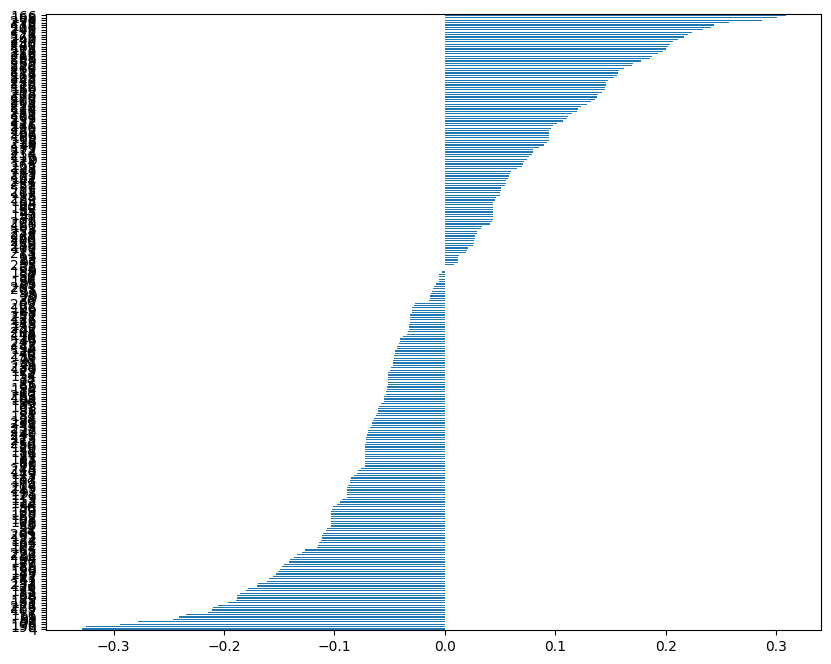

In [14]:
correlations = df.corr()['target'].drop('target').dropna().sort_values()
correlations.plot(kind='barh', figsize=(10, 8))

max_corr = correlations.abs().idxmax()
print(f"Max correlation: {max_corr} ({correlations[max_corr]})")


In [15]:
protected_attr_mappings = {}
for column in df.columns:
    if df[column].nunique() == 2 and column != h.predicted_attr:
        protected_attr_mappings[column] = {"Privileged": df[column].value_counts().idxmax(), "Unprivileged": df[column].value_counts().idxmin()}
protected_attr_mappings

{1: {'Privileged': 1, 'Unprivileged': 0},
 21: {'Privileged': 0, 'Unprivileged': 1},
 22: {'Privileged': 0, 'Unprivileged': 1},
 23: {'Privileged': 0, 'Unprivileged': 1},
 24: {'Privileged': 0, 'Unprivileged': 1},
 25: {'Privileged': 0, 'Unprivileged': 1},
 26: {'Privileged': 0, 'Unprivileged': 1},
 33: {'Privileged': 0, 'Unprivileged': 1},
 34: {'Privileged': 0, 'Unprivileged': 1},
 35: {'Privileged': 0, 'Unprivileged': 1},
 36: {'Privileged': 0, 'Unprivileged': 1},
 37: {'Privileged': 0, 'Unprivileged': 1},
 38: {'Privileged': 0, 'Unprivileged': 1},
 45: {'Privileged': 0, 'Unprivileged': 1},
 46: {'Privileged': 0, 'Unprivileged': 1},
 47: {'Privileged': 0, 'Unprivileged': 1},
 48: {'Privileged': 0, 'Unprivileged': 1},
 49: {'Privileged': 0, 'Unprivileged': 1},
 50: {'Privileged': 0, 'Unprivileged': 1},
 55: {'Privileged': 0, 'Unprivileged': 32},
 57: {'Privileged': 0, 'Unprivileged': 1},
 58: {'Privileged': 0, 'Unprivileged': 1},
 59: {'Privileged': 0, 'Unprivileged': 1},
 60: {'Priv

In [16]:
h.protected_attr_mappings = protected_attr_mappings
h.protected_attr = list(protected_attr_mappings.keys())
h.get_metrics(correlated_vars=max_corr,
    df_train=df)

/home/diego/git/SBCAS2025_Diego_PreTrainingBias/.venv/lib/python3.10/site-packages/sbcasdiego/PreTrainingBias/PreTrainingBias.py:16: RuntimeWarning: divide by zero encountered in log
  return np.sum(p * np.log(p / q))
/home/diego/git/SBCAS2025_Diego_PreTrainingBias/.venv/lib/python3.10/site-packages/sbcasdiego/PreTrainingBias/PreTrainingBias.py:16: RuntimeWarning: invalid value encountered in double_scalars
  return np.sum(p * np.log(p / q))


{'Class Imbalance': {1: 0.10176991150442478,
  21: -0.995575221238938,
  22: -0.9778761061946902,
  23: -0.9778761061946902,
  24: -0.9911504424778761,
  25: -0.9911504424778761,
  26: -0.9823008849557522,
  33: -0.9646017699115044,
  34: -0.9424778761061947,
  35: -0.995575221238938,
  36: -0.9911504424778761,
  37: -0.9911504424778761,
  38: -0.9690265486725663,
  45: -0.995575221238938,
  46: -0.9292035398230089,
  47: -0.995575221238938,
  48: -0.9646017699115044,
  49: -0.9778761061946902,
  50: -0.9911504424778761,
  55: -1.0,
  57: -0.9778761061946902,
  58: -0.9911504424778761,
  59: -0.9911504424778761,
  60: -0.9911504424778761,
  61: -0.9911504424778761,
  62: -0.9823008849557522,
  70: -0.9646017699115044,
  71: -0.995575221238938,
  72: -0.995575221238938,
  73: -0.9867256637168141,
  74: -0.995575221238938,
  81: -0.9911504424778761,
  82: -0.9513274336283186,
  84: -0.995575221238938,
  85: -0.995575221238938,
  86: -0.995575221238938,
  93: -0.9867256637168141,
  94: -0